# Figure 2 top row + AudioMAE on SC 20-word and NSynth

Reproduces the **first row** of the combined figure in `figure_2.ipynb` (four panels: ESC-50, SC 20-word, WSN 794-word, NSynth instrument), using the same `to_plot` filters and grouped bar layout.

**AudioMAE** bars are added only for **20-word classification** and **NSynth**, from linear-probe pickles written by:

- `lightning_scripts/eval_speech_commands_transfer.py` with `--model_type audiomae` → `eval_jsin_results/linear_eval_speech_commands/audiomae_pretrained_*.pkl`
- `lightning_scripts/eval_nsynth_linear.py` with `--encoder_type audiomae` → `eval_nsynth_results/audiomae_pretrained_nsynth_family_linear_eval_*.pkl`

Set `AUDIOMAE_PROBE_LAYER` in the loader cell to match your `layer_str` (e.g. `norm`).

Empty result directories are handled with a fixed column schema so `from_records([])` does not raise `KeyError`.


In [3]:

import numpy as np
import pandas as pd
import re
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys


def _find_repo_root() -> Path:
    """Notebook cwd may be repo root or notebooks/; data live next to figure_utils.py."""
    cwd = Path.cwd().resolve()
    for d in [cwd, *list(cwd.parents)[:8]]:
        if (d / "figure_utils.py").is_file():
            return d
    return cwd


REPO_ROOT = _find_repo_root()
print("REPO_ROOT:", REPO_ROOT.resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import figure_utils
from importlib import reload
reload(figure_utils)
from figure_utils import (
    format_model_str,
    format_model_str_word_task,
    format_model_str_nsynth,
    normalize_model_name,
    build_model_palette,
    get_standard_hue_order,
    get_standard_base_colors,
    get_model_groups,
    model_label,
    set_bar_labels,
)

hue_order = get_standard_hue_order()
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)

fig_out_dir = REPO_ROOT / "CCN_2026_figs"
fig_out_dir.mkdir(parents=True, exist_ok=True)

AUDIOMAE_BAR_COLOR = "#7570b3"
hue_dict["AudioMAE"] = AUDIOMAE_BAR_COLOR


def _df_from_records_or_empty(records, columns):
    """Empty lists must not use from_records([]) (no columns). Always return expected schema."""
    if not records:
        return pd.DataFrame(columns=columns)
    return pd.DataFrame.from_records(records)



REPO_ROOT: /mnt/ceph/users/igriffith/projects/cochdnn


## ESC-50 results (CochCNN9 / BYOL-A pickles)


In [4]:
path_to_esc_results = REPO_ROOT / "esc_analysis"

all_model_results = list(path_to_esc_results.rglob("*barlow*kell2018*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("audioset_*/saved_vars*.pickle"))
# all_model_results += list(path_to_esc_results.rglob("*resnet*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("kell2018_barlow*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("kell2018*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("word_kell2018*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("config_linear*/saved_vars*.pickle"))
all_model_results += list(path_to_esc_results.rglob("byola*/saved_vars*.pickle"))
# all_model_results

test_layers = [
                'preproc',
                'batchnorm0',
                'conv0',
                'relu0',
                'maxpool0',
                'batchnorm1',
                'conv1',
                'relu1',
                'maxpool1',
                'batchnorm2',
                'conv2',
                'relu2',
                'conv3',
                'relu3',
                'conv4',
                'relu4',
                'avgpool',
                'fullyconnected',
                'relufc',
                'dropout',
                ]
                
resnet18_layer_order = [
                'preproc',
                'conv1',
                'bn1',
                'relu1',
                'maxpool1',
                'layer1',
                'layer2',
                'layer3',
                'layer4',
                'avgpool',
            ]            
layer_order_dict = {l:i for i,l in enumerate(test_layers)}
df_list = []

for i, results_path in enumerate(all_model_results):
    path_str = str(results_path)

    if 'kell2018' in path_str and not results_path.parent.stem.startswith('kell2018'):
        if 'eq_lmbda' in path_str:
            # if 'fixed_loss' not in path_str:
            continue 
    
    if "resnet18" in path_str:
        if "barlow" in path_str:
            if "invar_augment" not in path_str and "audioset" not in path_str:
                continue
    # Do not skip paths containing "projects": repo roots often live under .../projects/...,
    # which would drop every pickle when using absolute REPO_ROOT paths.
    results = pd.read_pickle(results_path)
    overall_acc = results['overall_acc']
    top1_std = np.std(results['avg_accuracies'])

    model_name, arch_class, test_layer, eq_lmbda = format_model_str(results_path)
    
    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda, overall_acc=overall_acc, top1_std=top1_std)
    if i == 0:
        category_list = np.array(list(results['target_to_category'].values()))

    df_list.append(data)

_esc_cols = ["model_name", "arch_class", "test_layer", "eq_lmbda", "overall_acc", "top1_std"]
esc_50_df = _df_from_records_or_empty(df_list, _esc_cols)
if not esc_50_df.empty:
    esc_50_df["test_layer"] = esc_50_df["test_layer"].astype("str")
    esc_50_df["model_name"] = esc_50_df["model_name"].apply(normalize_model_name)
    esc_50_df = esc_50_df.loc[
        esc_50_df["test_layer"]
        .map({k: i for i, k in enumerate(test_layers)})
        .sort_values()
        .index
    ]
    esc_50_df = esc_50_df[~esc_50_df.model_name.str.contains("1.0|0.8|dual", na=False)]
esc_50_df["task"] = "ESC-50"


## Speech commands (included for concat parity with `figure_2`)


In [5]:
path_to_speech_commands_results = REPO_ROOT / "eval_jsin_results/linear_eval_speech_commands"
kell2018_speech_commands_results = list(path_to_speech_commands_results.rglob("*kell2018*full*cosine*.pkl"))
kell2018_speech_commands_results = [path for path in kell2018_speech_commands_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'mmcr']])]

resnet18_speech_commands_results = list(path_to_speech_commands_results.rglob("resnet18*.pkl"))
resnet18_speech_commands_results = [path for path in resnet18_speech_commands_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop']])]

byola_results =  list(path_to_speech_commands_results.rglob("config_*cosine*.pkl"))

all_speech_commands_task_results = kell2018_speech_commands_results + resnet18_speech_commands_results + byola_results

df_list = []

for i, results_path in enumerate(all_speech_commands_task_results):
    path_str = str(results_path)

    if 'kell2018' in path_str and not results_path.name.startswith('kell2018'):
        if 'eq_lmbda' in path_str:

            # if 'fixed_loss' not in path_str:
            continue 
    if "resnet18" in path_str:
        if "barlow" in path_str and "invar_augment" not in path_str:
            continue
    if "equivariant" in path_str and not "cosine" in path_str:
        continue 


    results = pd.read_pickle(results_path)
    # break 

    model_name, arch_class, _, eq_lmbda = format_model_str_word_task(results_path)
    if arch_class == 'unknown' and 'config_' in path_str:
        model_name = 'byol-a'
        arch_class = 'byol-a'
        eq_lmbda = ''
    
    # Remove audioset modifiers before normalization if we have explicit eq_lmbda
    # to prevent normalize_model_name from adding another lambda
    if eq_lmbda and 'ssl' in model_name:
        model_name = re.sub(
            r'\s+(?:jsin\s+)?audioset|\s+unbalanced\s+audioset',
            '',
            model_name,
        )
        model_name = re.sub(r'\s{2,}', ' ', model_name).strip()
    
    # Normalize the model name
    model_name = normalize_model_name(model_name)
    
    test_layer = path_str.split('AdamW_')[-1].split('_')[0]
    if model_name == 'byol-a':
        test_layer = 'final'

    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda)
    data = {**data, **results}


    df_list.append(data)

_speech_cols = ["model_name", "arch_class", "test_layer", "eq_lmbda"]
speech_commands_df = _df_from_records_or_empty(df_list, _speech_cols)
if not speech_commands_df.empty:
    speech_commands_df["test_layer"] = speech_commands_df["test_layer"].astype("str")
speech_commands_df["task"] = "20-word classification"


## 800-word classification


In [6]:
path_to_word_results = REPO_ROOT / "eval_jsin_results"

kell2018_word_results = list(path_to_word_results.rglob("*kell2018*.pkl"))
kell2018_word_results = [path for path in kell2018_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

# resnet18_word_results = list(path_to_word_results.rglob("*resnet18*.pkl"))
# resnet18_word_results = [path for path in resnet18_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

# resnet50_word_results = list(path_to_word_results.rglob("*resnet50*.pkl"))
# resnet50_word_results = [path for path in resnet50_word_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands']])]

byola_results =  list(path_to_word_results.rglob("config_linear*.pkl"))
byola_results = [path for path in byola_results if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands', '0.01']])]

byola_results_new =  list(path_to_word_results.rglob("byola*.pkl"))
byola_results += [path for path in byola_results_new if not any([substr in str(path) for substr in ['with_noise', 'middle_crop', 'speech_commands', '0.01']])]

all_word_task_results = kell2018_word_results + byola_results # + resnet18_word_results + resnet50_word_results +

df_list = []

for i, results_path in enumerate(all_word_task_results):
    path_str = str(results_path)
    # if results_path.name.startswith('audioset'):
    #     print(path_str)

    if 'kell2018' in path_str and not results_path.name.startswith('kell2018'):
        if 'eq_lmbda' in path_str:

            # if 'fixed_loss' not in path_str:
            continue 
    if 'kell2018' in path_str and not 'w_dropout_center_eval_words' in path_str:

        continue
    if "resnet18" in path_str:
        if "barlow" in path_str and "invar_augment" not in path_str:
            continue
    if not any([layer in str(results_path) for layer in test_layers + resnet18_layer_order]):

        continue 

    results = pd.read_pickle(results_path)
    # break 

    model_name, arch_class, test_layer, eq_lmbda = format_model_str_word_task(results_path)

    # get learning rate from path. E.g. pattern AdamW_0.01_ should get 0.01, AdamW_1e-05 should get 1e-05
    try:
        pattern = r'AdamW_([0-9]+(?:\.[0-9]+)?(?:e-?[0-9]+)?)_'
        match = re.search(pattern, path_str)
        if match:
            learning_rate = match.group(1)
        else:
            learning_rate = None

    except:
        print(f"No learning rate found for {path_str}")
        learning_rate = None

    if learning_rate == "0.0005":
        if "scaled" not in normalize_model_name(model_name):
            continue
    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda, learning_rate=learning_rate)
    data = {**data, **results}


    df_list.append(data)

_word_cols = ["model_name", "arch_class", "test_layer", "eq_lmbda", "learning_rate"]
word_df = _df_from_records_or_empty(df_list, _word_cols)
if not word_df.empty:
    word_df["test_layer"] = word_df["test_layer"].astype("str")
    word_df["model_name"] = word_df["model_name"].apply(normalize_model_name)
    word_df.loc[word_df.model_name.str.contains("byol-a"), "arch_class"] = "byol-a"
    word_df = word_df[
        ~(word_df.model_name.str.contains("byol-a") & (word_df.test_layer != "features"))
    ]
word_df["task"] = "800-word classification"



## NSynth


In [7]:
path_to_nsynth_results = REPO_ROOT / "eval_nsynth_results"

all_model_results = list(path_to_nsynth_results.rglob("audioset_*nsynth*.pkl"))
# all_model_results += list(path_to_nsynth_results.rglob("resnet18_barlow*nsynth*.pkl"))
# all_model_results += list(path_to_nsynth_results.rglob("resnet50_barlow*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("kell2018*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("word_kell2018*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("config_*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("byola*nsynth*.pkl"))

df_list = []

for i, results_path in enumerate(all_model_results):
    path_str = str(results_path)

    results = pd.read_pickle(results_path)
    overall_acc = results['top1_mean']
    # Get error if available
    top1_sem = results.get('top1_sem', None)

    model_name, arch_class, test_layer, eq_lmbda = format_model_str_nsynth(results_path)
    
    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda, overall_acc=overall_acc)
    if top1_sem is not None:
        data['top1_sem'] = top1_sem

    df_list.append(data)

_nsynth_cols = ["model_name", "arch_class", "test_layer", "eq_lmbda", "overall_acc", "top1_sem"]
nsynth_df = _df_from_records_or_empty(df_list, _nsynth_cols)
if not nsynth_df.empty:
    nsynth_df["test_layer"] = nsynth_df["test_layer"].astype("str")
    nsynth_df["model_name"] = nsynth_df["model_name"].apply(normalize_model_name)
    nsynth_df = nsynth_df.loc[
        nsynth_df["test_layer"]
        .map({k: i for i, k in enumerate(test_layers)})
        .sort_values()
        .index
    ]
nsynth_df["task"] = "NSynth"


In [8]:
df = pd.concat([esc_50_df, speech_commands_df, word_df, nsynth_df], axis=0, ignore_index=True)
# Empty loaders use minimal column lists; plotting uses dropna(subset=[val_col]) on all tasks.
for _col in ("overall_acc", "top1_std", "word_top1_mean", "word_top1_sem", "top1_sem"):
    if _col not in df.columns:
        df[_col] = np.nan


In [9]:

# SSL models: sync eq_lmbda from model name
re_pattern = r'ssl λ=([0-9.]+)'
df.loc[df.model_name.str.contains('ssl λ=', na=False), 'eq_lmbda'] = (
    df.loc[df.model_name.str.contains('ssl λ=', na=False)].model_name.str.extract(re_pattern)[0]
)



## Append AudioMAE rows (SC 20-word + NSynth linear probes)


In [10]:
# Layer name must match --layer_str in eval_audiomae_speech_commands.sh / eval_audiomae_nsynth.sh
AUDIOMAE_PROBE_LAYER = "norm"

def _latest_pkl(paths):
    if not paths:
        return None
    return max(paths, key=lambda p: p.stat().st_mtime)

am_rows = []

# Filenames include AdamW_<layer>_ in the modifier (avoid *block_1* matching block_10)
_speech_token = f"AdamW_{AUDIOMAE_PROBE_LAYER}_"

speech_dir = REPO_ROOT / "eval_jsin_results/linear_eval_speech_commands"
if speech_dir.is_dir():
    sc_candidates = [
        p for p in speech_dir.glob("audiomae_pretrained_*.pkl") if _speech_token in p.name
    ]
    sp = _latest_pkl(sc_candidates)
    if sp is not None:
        d = pd.read_pickle(sp)
        am_rows.append(
            dict(
                model_name="AudioMAE",
                arch_class="audiomae",
                test_layer=AUDIOMAE_PROBE_LAYER,
                eq_lmbda="",
                task="20-word classification",
                word_top1_mean=d["word_top1_mean"],
                word_top1_sem=d["word_top1_sem"],
            )
        )
        print("AudioMAE speech commands:", sp.name)
    else:
        print("No audiomae pkl with", _speech_token, "under", speech_dir)
else:
    print("Missing directory", speech_dir)

nsynth_dir = REPO_ROOT / "eval_nsynth_results"
if nsynth_dir.is_dir():
    _ns_token = f"AdamW_{AUDIOMAE_PROBE_LAYER}_"
    ns_candidates = [
        p
        for p in nsynth_dir.glob(
            "audiomae_pretrained_nsynth_family_linear_eval_*.pkl"
        )
        if _ns_token in p.name
    ]
    npk = _latest_pkl(ns_candidates)
    if npk is not None:
        d = pd.read_pickle(npk)
        am_rows.append(
            dict(
                model_name="AudioMAE",
                arch_class="audiomae",
                test_layer=AUDIOMAE_PROBE_LAYER,
                eq_lmbda="",
                task="NSynth",
                overall_acc=d["top1_mean"],
                top1_sem=d["top1_sem"],
            )
        )
        print("AudioMAE NSynth:", npk.name)
    else:
        print("No NSynth audiomae pkl with", _ns_token, "under", nsynth_dir)
else:
    print("Missing directory", nsynth_dir)

if am_rows:
    df = pd.concat([df, pd.DataFrame(am_rows)], ignore_index=True)


AudioMAE speech commands: audiomae_pretrained_AdamW_norm_0.1_cosine_lr_scheduler_.pkl
AudioMAE NSynth: audiomae_pretrained_nsynth_family_linear_eval_AdamW_norm_0.001_cosine_lr_scheduler_.pkl


## Top row: four tasks (Figure 2 style) + AudioMAE on SC & NSynth


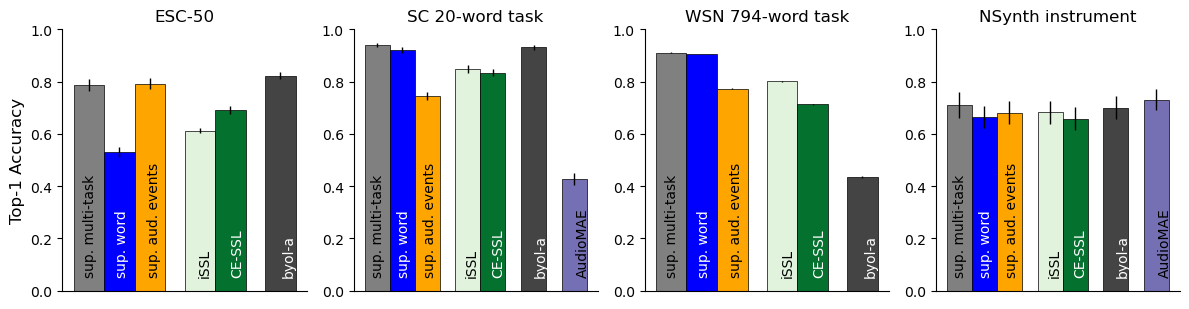

In [ ]:
reload(figure_utils)

tasks = [
    ("ESC-50", "overall_acc", "top1_std"),
    ("20-word classification", "word_top1_mean", "word_top1_sem"),
    ("800-word classification", "word_top1_mean", "word_top1_sem"),
    ("NSynth", "overall_acc", "top1_sem"),
]
titles = ["ESC-50", "SC 20-word task", "WSN 794-word task", "NSynth instrument"]

supervised_names, ssl_names, _scaled_ssl_names, byol_names = get_model_groups(hue_order)
plot_groups = [
    ("Supervised", supervised_names),
    ("SSL", ssl_names),
    ("BYOL-A", byol_names),
    ("AudioMAE", ["AudioMAE"]),
]

to_plot = df[
    ~df["model_name"].str.contains("scaled", na=False)
    & ~df["model_name"].str.contains("dual", na=False)
    & (
        df["test_layer"].str.contains("relu4", na=False)
        | (
            (df["model_name"] == "byol-a")
            & df["test_layer"].str.contains("final|features", na=False, regex=True)
        )
        | (
            (df["model_name"] == "AudioMAE")
            & (df["test_layer"].astype(str) == AUDIOMAE_PROBE_LAYER)
        )
    )
    & (
        ~df["model_name"].str.contains("ssl", na=False)
        | (
            df["eq_lmbda"].isin(["0.0", "0.5", "", None])
            | df["eq_lmbda"].isna()
        )
    )
].copy()

fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
bar_width = 0.8
group_gap = 0.5
fontsize = 12

for ax, (task, val_col, err_col), title in zip(axes, tasks, titles):
    task_df = to_plot[to_plot["task"] == task].dropna(subset=[val_col])
    means = task_df.groupby("model_name")[val_col].mean()
    errors = (
        task_df.groupby("model_name")[err_col].mean()
        if err_col in task_df.columns
        else None
    )

    x_cursor = 0.1
    for group_name, models in plot_groups:
        models = [m for m in models if m in means.index]
        if len(models) == 0:
            continue
        for i, model in enumerate(models):
            x = x_cursor + i * bar_width
            color = hue_dict.get(model, "#666666")
            label = model_label(model, use_ssl_names=True)
            bars = ax.bar(
                x,
                means.loc[model],
                width=bar_width,
                color=color,
                edgecolor="black",
                linewidth=0.5,
            )
            error = []
            if errors is not None and model in errors.index:
                error = [errors.loc[model]]
                ax.errorbar(
                    x,
                    means.loc[model],
                    yerr=errors.loc[model],
                    fmt="none",
                    color="black",
                    capsize=0,
                    linewidth=1,
                )
            # set_bar_labels(
            #     ax,
            #     bars,
            #     [label],
            #     white_text_substrs=["word", "CE", "byol"],
            #     # y_cut_for_olap=0.3,
            #     ymin_bars=0.4,
            #     no_olap_pad=0.04,
            #     x_shift_size=0.0,
            #     fontsize=10,
            # )

            set_bar_labels(ax, bars, [label],
                white_text_substrs=["word", "CE", "byol"],
                ymin_bars=0.05,
                no_olap_pad=0.04,
                fontsize=10,
                sem_vals=error)
                
        x_cursor += len(models) * bar_width + group_gap

    ax.set_xticks([])
    ax.set_xticklabels([], rotation=70, ha="right")
    ax.set_ylabel("", fontsize=fontsize)
    if "ESC" in task:
        ax.set_ylabel("Top-1 Accuracy", fontsize=fontsize)
    ax.set_title(title, fontsize=fontsize)
    ax.set_ylim(0, 1.0)

sns.despine()
plt.subplots_adjust(wspace=0.25)
plt.tight_layout()
# plt.savefig(fig_out_dir / "figure2_top_row_plus_audiomae.pdf", bbox_inches="tight")
plt.show()


[np.float64(0.02188606862823928)]